# Experiment 05 — Dataset Size Scaling

**Research question:** How does the amount of training data affect VQC performance?

**Setup:** Fixed 2 features (cols 26, 4), 2 layers, angle encoding.  
We vary the total dataset size: **500 → 1000 → 5000 → 10000**.

### Why this matters
- The paper notes that VQCs may be particularly advantageous with *limited data*
- Quantum models have fewer parameters → potentially better generalisation at small N
- At large N, classical models usually dominate due to scalability

| Dataset Size | Train | Val | Test |
|-------------|-------|-----|------|
| 500 | 300 | 100 | 100 |
| 1,000 | 600 | 200 | 200 |
| 5,000 | 3,000 | 1,000 | 1,000 |
| 10,000 | 6,000 | 2,000 | 2,000 |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import time
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score, roc_curve

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

## 1. Setup

In [2]:
# Fixed architecture
N_FEATURES = 2
N_LAYERS   = 2
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01

DATASET_SIZES = [500, 1000, 5000, 10000]

## 2. Circuit and Training

In [3]:
dev = qml.device('default.qubit', wires=N_FEATURES)

@qml.qnode(dev, interface='autograd')
def circuit(weights, x):
    for i in range(N_FEATURES):
        qml.RY(x[i], wires=i)
    for l in range(N_LAYERS):
        for q in range(N_FEATURES):
            qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(0))


def train_vqc(X_train, y_train, X_val, y_val, n_epochs, batch_size, lr):
    """Train the fixed-architecture VQC."""
    weights = pnp.array(
        np.random.uniform(0, 2*np.pi, (N_LAYERS, N_FEATURES, 3)),
        requires_grad=True
    )
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=lr)

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, len(X_train), batch_size):
            Xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size].astype(float)

            def cost(w, b):
                preds = pnp.array([circuit(w, x) + b for x in Xb])
                return pnp.mean((yb - preds) ** 2)

            weights, bias = opt.step(cost, weights, bias)

        # Epoch-level metrics
        tr_preds = pnp.array([circuit(weights, x) + bias for x in X_train])
        vl_preds = pnp.array([circuit(weights, x) + bias for x in X_val])
        tr_loss = float(pnp.mean((y_train.astype(float) - tr_preds)**2))
        vl_loss = float(pnp.mean((y_val.astype(float) - vl_preds)**2))
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1}/{n_epochs} | '
                  f'train_loss={tr_loss:.4f}, val_loss={vl_loss:.4f}')

    return weights, bias, train_losses, val_losses

## 3. Run Dataset Size Experiments

In [4]:
results = {}

for n_samples in DATASET_SIZES:
    print(f'\n{"="*50}')
    print(f'Running: {n_samples} samples')

    X_tr, X_vl, X_te, y_tr, y_vl, y_te = load_higgs(
        path='../data/HIGGS.csv.gz',
        n_samples=n_samples,
        n_features=N_FEATURES,
        feature_indices=[26, 4],
        scale_range=(0, np.pi),
    )

    np.random.seed(42)
    t0 = time.time()
    weights, bias, tr_loss, vl_loss = train_vqc(
        X_tr, y_tr, X_vl, y_vl, N_EPOCHS, BATCH_SIZE, LR
    )
    wall_time = time.time() - t0

    # Test evaluation
    test_raw = np.array([float(circuit(weights, x) + bias) for x in X_te])
    test_acc = binary_accuracy(y_te, test_raw)
    y_te_01 = (y_te == 1).astype(int)
    test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
    test_auc = roc_auc_score(y_te_01, test_score)

    # Train-val gap (overfitting indicator)
    final_gap = tr_loss[-1] - vl_loss[-1]

    results[n_samples] = {
        'train_losses': tr_loss,
        'val_losses': vl_loss,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'test_scores': test_score,
        'y_test_01': y_te_01,
        'wall_time': wall_time,
        'train_val_gap': final_gap,
    }
    print(f'  → Test acc: {test_acc:.4f} | Test AUC: {test_auc:.4f} | '
          f'Time: {wall_time:.1f}s | Gap: {final_gap:.4f}')


Running: 500 samples
Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 500 samples | 2 features | train=300, val=100, test=100
  Epoch 1/30 | train_loss=0.8820, val_loss=0.9167
  Epoch 10/30 | train_loss=0.8746, val_loss=0.9233
  Epoch 20/30 | train_loss=0.8736, val_loss=0.9318
  Epoch 30/30 | train_loss=0.8732, val_loss=0.9313
  → Test acc: 0.7200 | Test AUC: 0.6842 | Time: 40.7s | Gap: -0.0581

Running: 1000 samples
Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 1000 samples | 2 features | train=600, val=200, test=200
  Epoch 1/30 | train_loss=0.9451, val_loss=0.9519
  Epoch 10/30 | train_loss=0.9361, val_loss=0.9451
  Epoch 20/30 | train_loss=0.9290, val_loss=0.9444
  Epoch 30/30 | train_loss=0.9256, val_loss=0.9445
  → Test acc: 0.6900 | Test AUC: 0.6437 | Time: 81.9s | Gap: -0.0188

Running: 5000 samples
Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 5000 samples | 2 features | train=3000, val=1000, 

## 4. Results

In [5]:
print('\nDataset Size Scaling Results')
print(f'{"Samples":>10} {"Train":>8} {"Test Acc":>10} {"Test AUC":>10} {"Time(s)":>10} {"Tr-Val Gap":>12}')
print('-' * 64)
for ns, r in results.items():
    n_train = int(ns * 0.6)
    print(f'{ns:>10} {n_train:>8} {r["test_acc"]:>10.4f} {r["test_auc"]:>10.4f} '
          f'{r["wall_time"]:>10.1f} {r["train_val_gap"]:>12.4f}')


Dataset Size Scaling Results
   Samples    Train   Test Acc   Test AUC    Time(s)   Tr-Val Gap
----------------------------------------------------------------
       500      300     0.7200     0.6842       40.7      -0.0581
      1000      600     0.6900     0.6437       81.9      -0.0188
      5000     3000     0.6160     0.6087      534.2      -0.0030
     10000     6000     0.5970     0.5911      825.3      -0.0128


## 5. Plots

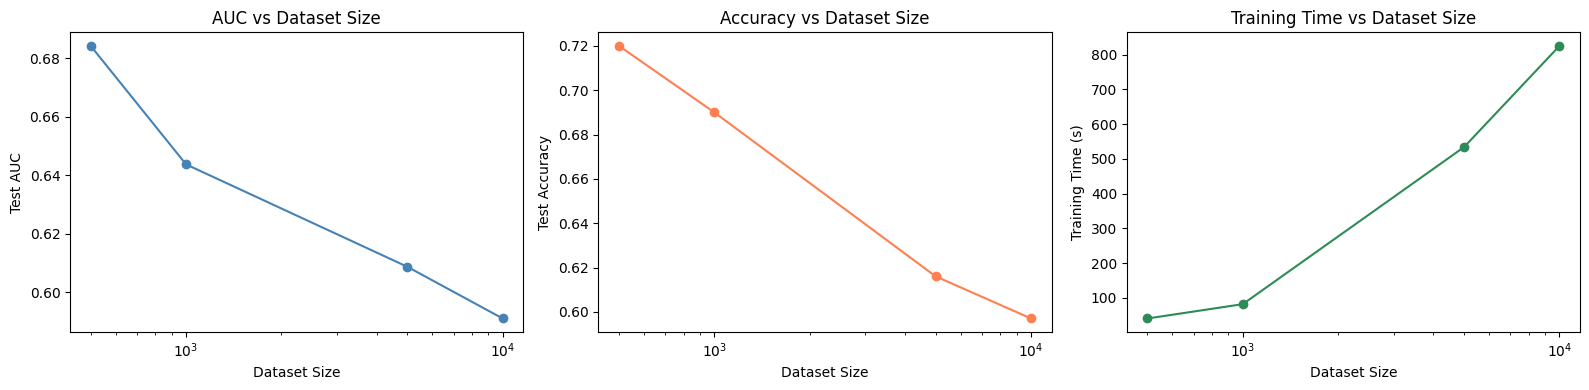

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sizes = list(results.keys())
aucs = [results[s]['test_auc'] for s in sizes]
accs = [results[s]['test_acc'] for s in sizes]
times = [results[s]['wall_time'] for s in sizes]

# AUC vs dataset size
axes[0].plot(sizes, aucs, 'o-', color='steelblue')
axes[0].set_xlabel('Dataset Size')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('AUC vs Dataset Size')
axes[0].set_xscale('log')

# Accuracy vs dataset size
axes[1].plot(sizes, accs, 'o-', color='coral')
axes[1].set_xlabel('Dataset Size')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy vs Dataset Size')
axes[1].set_xscale('log')

# Wall-clock time vs dataset size
axes[2].plot(sizes, times, 'o-', color='seagreen')
axes[2].set_xlabel('Dataset Size')
axes[2].set_ylabel('Training Time (s)')
axes[2].set_title('Training Time vs Dataset Size')
axes[2].set_xscale('log')

plt.tight_layout()
plt.savefig('../figures/05_dataset_size.png', dpi=150)
plt.show()

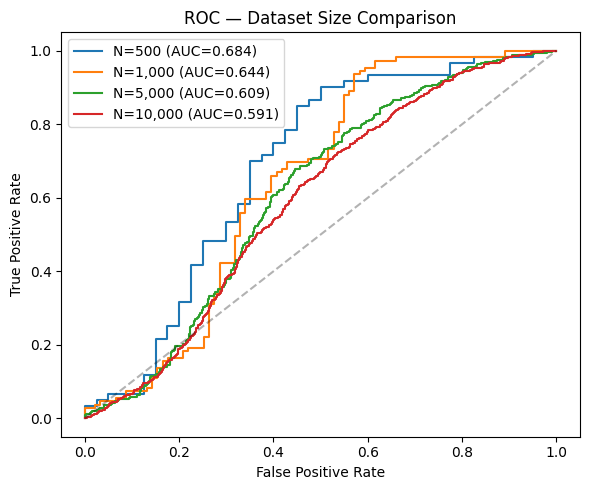

In [7]:
plt.figure(figsize=(6, 5))

for ns, r in results.items():
    fpr, tpr, _ = roc_curve(r['y_test_01'], r['test_scores'])
    plt.plot(fpr, tpr, label=f'N={ns:,} (AUC={r["test_auc"]:.3f})')

plt.plot([0,1],[0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — Dataset Size Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/05_roc_dataset_size.png', dpi=150)
plt.show()

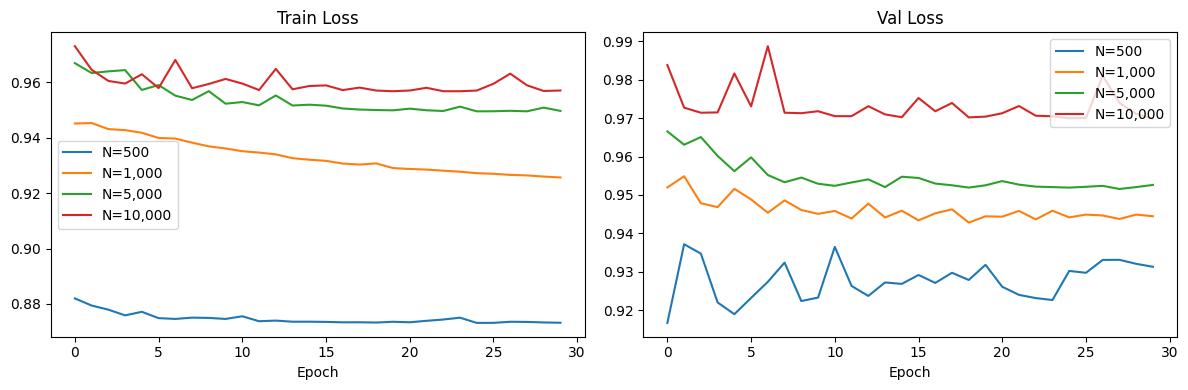

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ns, r in results.items():
    axes[0].plot(r['train_losses'], label=f'N={ns:,}')
    axes[1].plot(r['val_losses'], label=f'N={ns:,}')

axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Val Loss');   axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/05_training_curves.png', dpi=150)
plt.show()

## Observations

*(Fill in after running)*

- Does VQC performance improve with more data, or plateau quickly?
- At 500 samples, does the VQC still learn a useful classifier? (paper claims VQC is advantageous with limited data)
- Is there overfitting at small dataset sizes (large train-val gap)?
- How does training time scale with dataset size?
- Compare the N=5000 result with Experiment 01 as a sanity check — they should match.